# 01 - EDA & Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telco_churn.csv')  # place the raw Kaggle CSV in the same folder
print(df.shape)
print(df.info())
df.head()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)


In [3]:
print(df.isnull().sum())

# TotalCharges nulls usually correspond to tenure == 0 (new customers)
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

# fill with 0, since tenure = 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)



customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90   

In [4]:
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates: 0


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


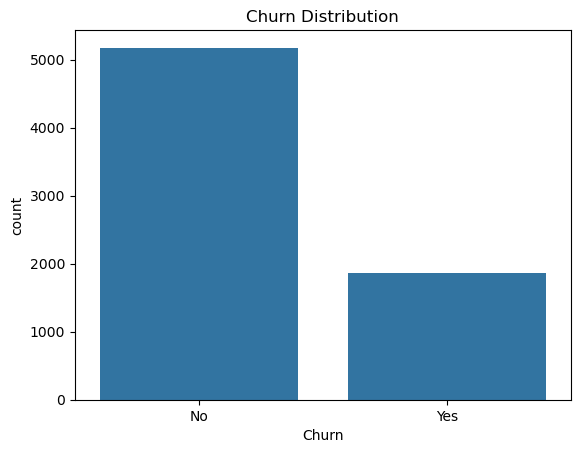

In [5]:
print(df['Churn'].value_counts(normalize=True))

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

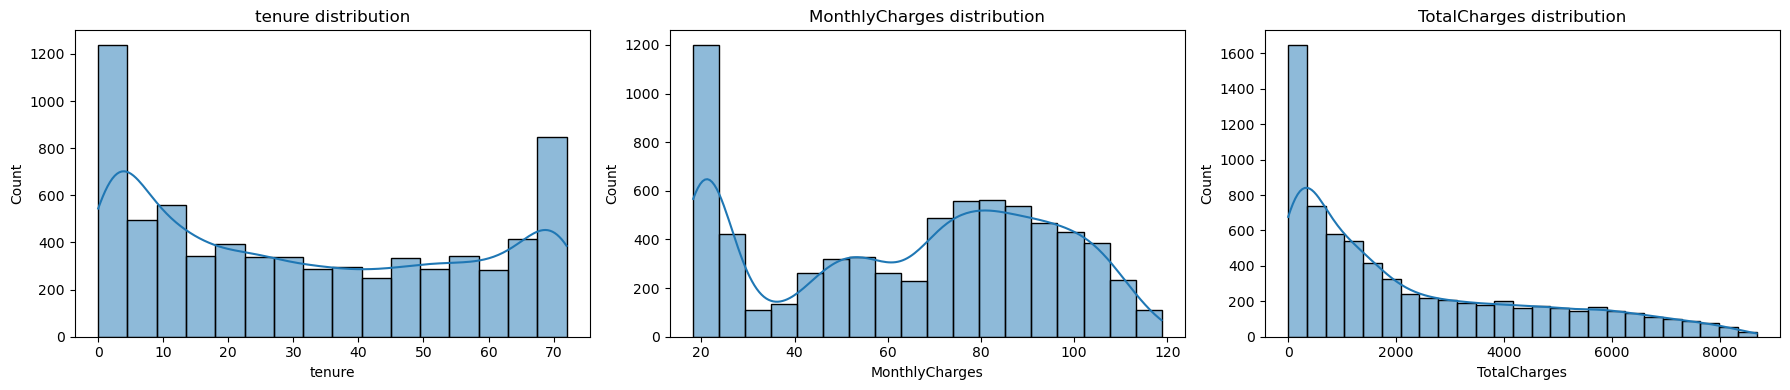

In [6]:
# Univariate EDA — numeric features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} distribution')
plt.tight_layout()
plt.show()


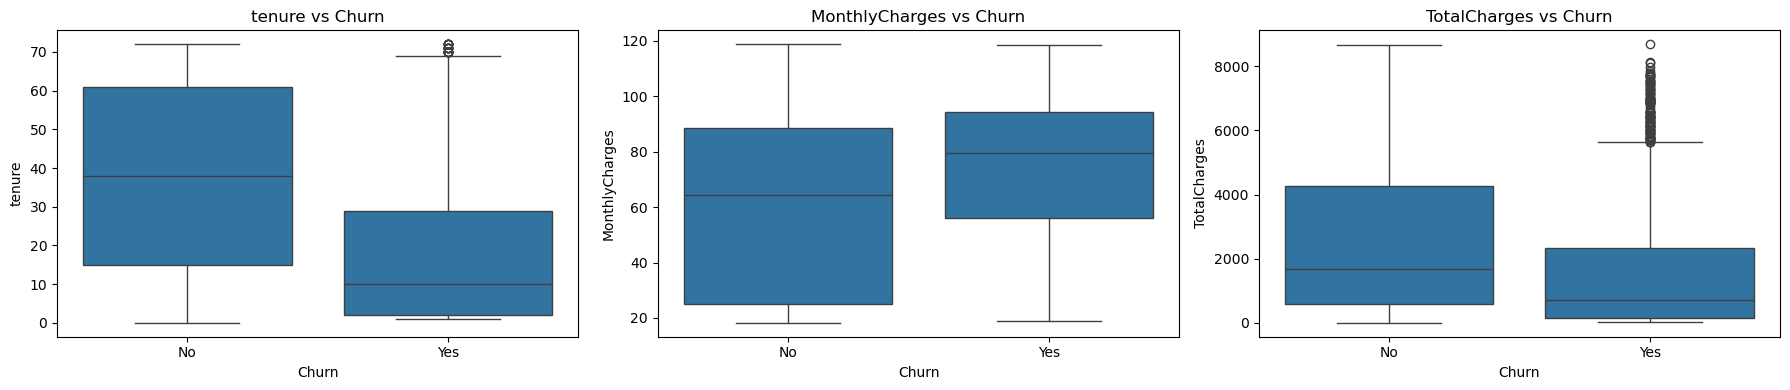

In [7]:
# Churn vs numeric features

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()


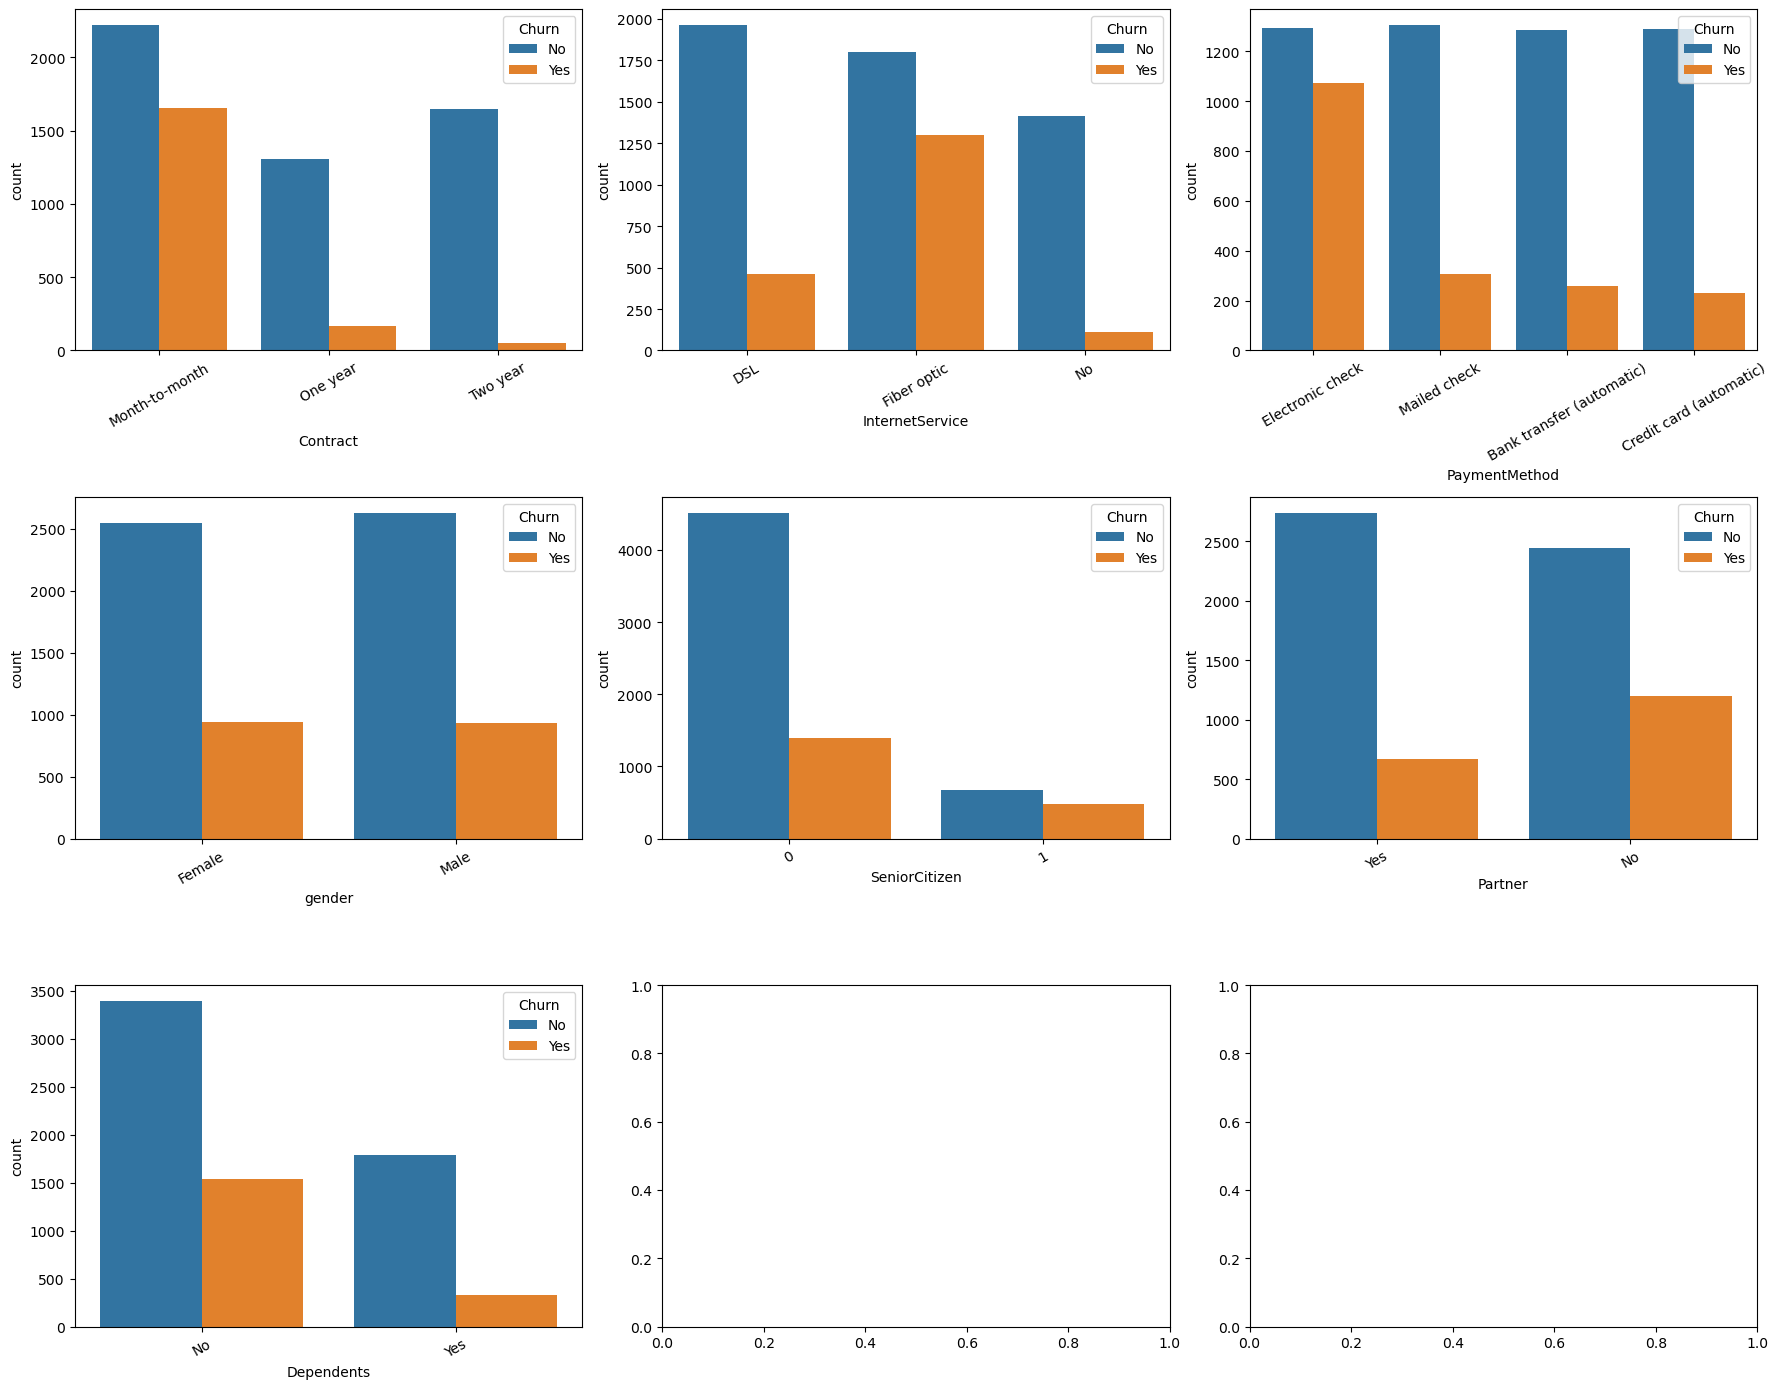

In [8]:
# Churn vs categorical features
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender',
            'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

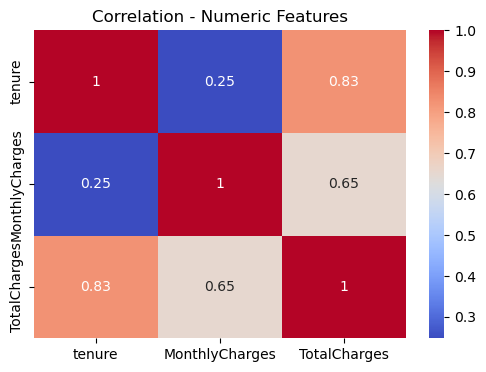

In [9]:
#  Correlation heatmap (numeric only)
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation - Numeric Features')
plt.show()

In [10]:
#  Outlier check (IQR method — reference only, not removing)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [11]:
#  Save cleaned datasetcsv
df.to_csv('telco_churn_cleaned.csv', index=False)
print("telco_churn_cleaned.")

telco_churn_cleaned.
